In [171]:
import pandas as pd

In [172]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [173]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [175]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [176]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [177]:
df.fillna(0, inplace=True)

In [178]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [179]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [180]:
df.drop_duplicates(inplace=True)

In [181]:
df.duplicated().sum()

np.int64(0)

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt


In [183]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


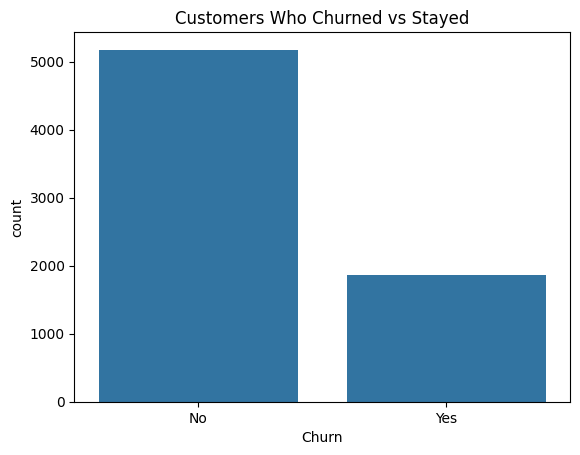

In [184]:
sns.countplot(x='Churn', data=df)
plt.title('Customers Who Churned vs Stayed')
plt.show()

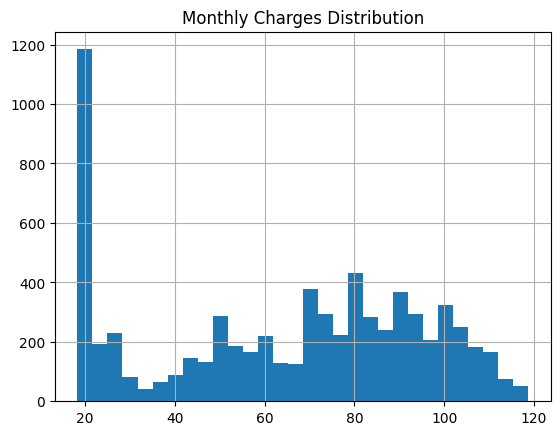

In [185]:
df["MonthlyCharges"].hist(bins=30)
plt.title('Monthly Charges Distribution')
plt.show()

In [186]:

df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


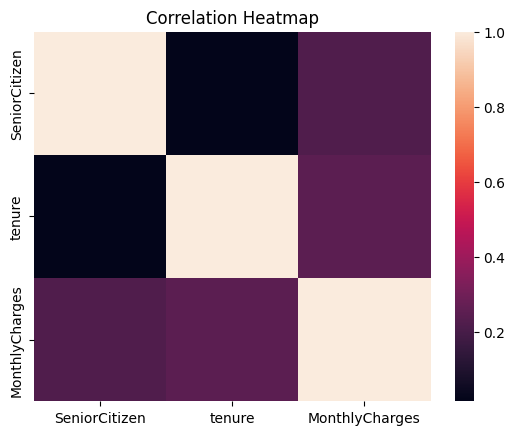

In [187]:
sns.heatmap(df.corr(numeric_only=True))
plt.title('Correlation Heatmap')
plt.show()

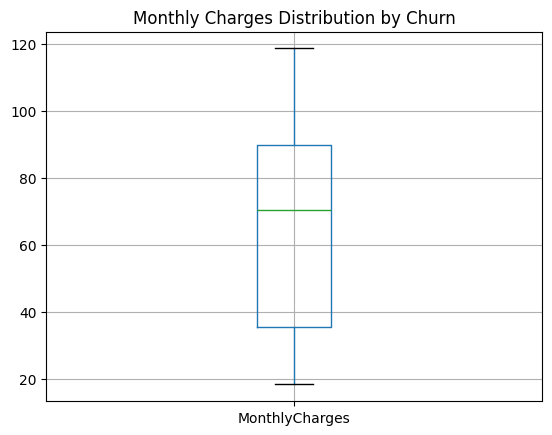

In [188]:
df.boxplot(column='MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

In [189]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR
df = df[(df['MonthlyCharges'] >= lower) &
(df['MonthlyCharges'] <= upper)]
print(lower)
print(upper)

-46.02499999999999
171.375


In [190]:
from sklearn.preprocessing import LabelEncoder

In [191]:
le=LabelEncoder()

In [192]:
df["gender"]=le.fit_transform(df["gender"])
df["Churn"]=le.fit_transform(df["Churn"])

In [193]:
df["gender"]

,gender
0,0
1,1
2,1
3,1
4,0
...,...
7038,1
7039,0
7040,0
7041,1


In [194]:
df["Churn"]

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [195]:
df=pd.get_dummies(df,columns=["Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"])

In [196]:
df.head()

,customerID,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,29.85,29.85,0,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,5575-GNVDE,1,0,34,56.95,1889.5,0,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,3668-QPYBK,1,0,2,53.85,108.15,1,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,7795-CFOCW,1,0,45,42.30,1840.75,0,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,9237-HQITU,0,0,2,70.70,151.65,1,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [197]:
from sklearn.preprocessing import StandardScaler

In [198]:
df["tenure"]

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


In [219]:
scalar=StandardScaler()
df['TotalCharges'].fillna(0, inplace=True)
df[['MonthlyCharges','TotalCharges']]=scalar.fit_transform(df[['MonthlyCharges','TotalCharges']])

/tmp/ipykernel_3117/899039096.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [220]:
df[["MonthlyCharges","TotalCharges"]]

,MonthlyCharges,TotalCharges
0,-1.160323,-0.992611
1,-0.259629,-0.172165
2,-0.362660,-0.958066
3,-0.746535,-0.193672
4,0.197365,-0.938874
...,...,...
7038,0.665992,-0.127605
7039,1.277533,2.242606
7040,-1.168632,-0.852932
7041,0.320338,-0.870513


In [202]:
from sklearn.model_selection import train_test_split

In [203]:
df["Churn"]=df["Churn"].astype(int)

In [204]:
x=df.drop(["Churn", "customerID"],axis=1)
y=df["Churn"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [207]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)

LogReg=lr.fit(x_train,y_train)

In [208]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)

RandomForest=rf.fit(x_train,y_train)

In [209]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

DecTree=dt.fit(x_train,y_train)

In [216]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

KNN=knn.fit(x_train,y_train)

In [211]:
from sklearn.metrics import (accuracy_score,confusion_matrix)
print("Logistic Regression")
print(accuracy_score(y_test,LogReg.predict(x_test)))
print(confusion_matrix(y_test,LogReg.predict(x_test)))
print("Random Forest Classifier")
print(accuracy_score(y_test,RandomForest.predict(x_test)))
print(confusion_matrix(y_test,RandomForest.predict(x_test)))
print("Decision Tree")
print(accuracy_score(y_test,DecTree.predict(x_test)))
print(confusion_matrix(y_test,DecTree.predict(x_test)))
print("KNN")
print(accuracy_score(y_test,KNN.predict(x_test)))
print(confusion_matrix(y_test,KNN.predict(x_test)))

Logistic Regression
0.8218594748048261
[[934 102]
 [149 224]]
Random Forest Classifier
0.7920511000709723
[[944  92]
 [201 172]]
Decision Tree
0.7175301632363378
[[828 208]
 [190 183]]
KNN
0.7679205110007097
[[891 145]
 [182 191]]


In [212]:
from sklearn.metrics import (accuracy_score,confusion_matrix)
print("Logistic Regression")
print(accuracy_score(y_test,LogReg.predict(x_test)))
print(confusion_matrix(y_test,LogReg.predict(x_test)))
print("Random Forest Classifier")
print(accuracy_score(y_test,RandomForest.predict(x_test)))
print(confusion_matrix(y_test,RandomForest.predict(x_test)))
print("Decision Tree")
print(accuracy_score(y_test,DecTree.predict(x_test)))
print(confusion_matrix(y_test,DecTree.predict(x_test)))
print("KNN")
print(accuracy_score(y_test,KNN.predict(x_test)))
print(confusion_matrix(y_test,KNN.predict(x_test)))

Logistic Regression
0.8218594748048261
[[934 102]
 [149 224]]
Random Forest Classifier
0.7920511000709723
[[944  92]
 [201 172]]
Decision Tree
0.7175301632363378
[[828 208]
 [190 183]]
KNN
0.7679205110007097
[[891 145]
 [182 191]]


In [213]:
lr_acc=accuracy_score(y_test,LogReg.predict(x_test))
rf_acc=accuracy_score(y_test,RandomForest.predict(x_test))
dt_acc=accuracy_score(y_test,DecTree.predict(x_test))
knn_acc=accuracy_score(y_test,KNN.predict(x_test))

In [214]:
accuracies=[lr_acc,rf_acc,dt_acc,knn_acc]
models=["Logistic Regression","Random Forest Classifier","Decision Tree","KNN"]
best=max(accuracies)
best_index=accuracies.index(best)
print("The best model is ",models[best_index])

The best model is  Logistic Regression


In [215]:
import joblib
joblib.dump(lr, "lr_model.pkl")
joblib.dump(df.head(), "df_head.pkl")

['df_head.pkl']